# Oil Price Time Series Forecasting - Complete Solution

## 1️⃣ Library Imports & Configuration

In [86]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Statistical analysis
from scipy import stats, signal
from scipy.optimize import minimize

# Machine learning metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Utilities
from datetime import timedelta
from itertools import product
import json

# Configuration
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

# Enable inline plotting
%matplotlib inline

print('✅ All libraries imported successfully!')
print(f'📊 NumPy version: {np.__version__}')
print(f'📈 Pandas version: {pd.__version__}')

✅ All libraries imported successfully!
📊 NumPy version: 1.26.4
📈 Pandas version: 2.2.2


## 2️⃣ Data Loading & Inspection

In [89]:
def load_and_inspect_data(filepath='oil_prices_2426.csv'):
    """
    Load oil price data and perform comprehensive initial inspection.
    
    Parameters:
    -----------
    filepath : str
        Path to the CSV file
        
    Returns:
    --------
    df : pd.DataFrame
        Cleaned DataFrame with datetime index
    """
    print('='*80)
    print('STEP 1: DATA LOADING AND INSPECTION')
    print('='*80)
    
    # Load data
    df = pd.read_csv(filepath, encoding='utf-8-sig')
    
    print(f'\n1.1 Initial Data Shape: {df.shape}')
    print(f'1.2 Column Names: {df.columns.tolist()}')
    
    # Clean column names
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    df.columns = df.columns.str.replace('(', '').str.replace(')', '')
    
    # Convert date column
    df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
    df = df.set_index('date').sort_index()
    df.columns = ['price']
    
    # Check data quality
    missing_count = df.isnull().sum().sum()
    print(f'\n1.3 Missing Values: {missing_count}')
    
    # Descriptive statistics
    print(f'\n1.4 DESCRIPTIVE STATISTICS:')
    print('-'*60)
    print(df.describe())
    
    # Time series information
    print(f'\n1.5 TIME SERIES INFORMATION:')
    print('-'*60)
    print(f'Start Date: {df.index.min()}')
    print(f'End Date: {df.index.max()}')
    print(f'Total Days: {len(df)}')
    print(f'Date Range: {(df.index.max() - df.index.min()).days} days')
    
    # Additional statistics
    print(f'\n1.6 ADDITIONAL STATISTICS:')
    print('-'*60)
    print(f'Mean: ${df["price"].mean():.2f}')
    print(f'Median: ${df["price"].median():.2f}')
    print(f'Std Dev: ${df["price"].std():.2f}')
    print(f'Coefficient of Variation: {(df["price"].std()/df["price"].mean())*100:.2f}%')
    print(f'Skewness: {df["price"].skew():.4f}')
    print(f'Kurtosis: {df["price"].kurtosis():.4f}')
    
    print('\n✓ Data loading complete!')
    return df

In [91]:
# Load the data
df = load_and_inspect_data('oil_prices_2426.csv')

# Display first and last rows
print('\n📊 First 5 rows:')
print(df.head())
print('\n📊 Last 5 rows:')
print(df.tail())

STEP 1: DATA LOADING AND INSPECTION

1.1 Initial Data Shape: (500, 2)
1.2 Column Names: ['date', 'price (dollars)']

1.3 Missing Values: 0

1.4 DESCRIPTIVE STATISTICS:
------------------------------------------------------------
          price
count  500.0000
mean    75.8740
std     42.9124
min     16.4800
25%     35.3725
50%     64.2900
75%    111.5725
max    158.7800

1.5 TIME SERIES INFORMATION:
------------------------------------------------------------
Start Date: 2024-09-21 00:00:00
End Date: 2026-02-02 00:00:00
Total Days: 500
Date Range: 499 days

1.6 ADDITIONAL STATISTICS:
------------------------------------------------------------
Mean: $75.87
Median: $64.29
Std Dev: $42.91
Coefficient of Variation: 56.56%
Skewness: 0.2897
Kurtosis: -1.3453

✓ Data loading complete!

📊 First 5 rows:
            price
date             
2024-09-21  32.10
2024-09-22  32.25
2024-09-23  31.07
2024-09-24  31.50
2024-09-25  32.21

📊 Last 5 rows:
             price
date              
2026-01-29  1

## 3️⃣ Exploratory Data Analysis (EDA)

In [94]:
def perform_comprehensive_eda(df):
    """
    Perform comprehensive exploratory data analysis with visualizations.
    
    Generates:
    - Time series plot with moving averages
    - Distribution analysis
    - Outlier detection
    - Daily returns analysis
    - Q-Q plot for normality
    """
    print('\n' + '='*80)
    print('STEP 2: EXPLORATORY DATA ANALYSIS')
    print('='*80)
    
    # Create comprehensive figure
    fig = plt.figure(figsize=(18, 14))
    gs = GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.3)
    
    # Calculate moving averages
    ma_30 = df['price'].rolling(window=30).mean()
    ma_90 = df['price'].rolling(window=90).mean()
    
    # Plot 1: Time Series with Moving Averages
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(df.index, df['price'], linewidth=1.2, color='#2E86AB', 
             alpha=0.7, label='Daily Price')
    ax1.plot(ma_30.index, ma_30, linewidth=2, color='#E63946', 
             alpha=0.8, label='30-Day MA')
    ax1.plot(ma_90.index, ma_90, linewidth=2, color='#06A77D', 
             alpha=0.8, label='90-Day MA')
    ax1.set_title('Oil Prices Over Time with Moving Averages', 
                  fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel('Date', fontsize=13)
    ax1.set_ylabel('Price (Dollars)', fontsize=13)
    ax1.legend(loc='best', fontsize=11)
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # Add statistics text box
    text_str = f"Mean: ${df['price'].mean():.2f}\n"
    text_str += f"Std: ${df['price'].std():.2f}\n"
    text_str += f"Min: ${df['price'].min():.2f}\n"
    text_str += f"Max: ${df['price'].max():.2f}"
    ax1.text(0.02, 0.97, text_str, transform=ax1.transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Plot 2: Distribution
    ax2 = fig.add_subplot(gs[1, 0])
    n, bins, patches = ax2.hist(df['price'], bins=50, density=True, 
                                 alpha=0.7, color='#A23B72', edgecolor='black')
    mu, sigma = df['price'].mean(), df['price'].std()
    x = np.linspace(df['price'].min(), df['price'].max(), 100)
    ax2.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2.5, 
             label='Normal Distribution')
    ax2.axvline(df['price'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: ${df["price"].mean():.2f}')
    ax2.set_title('Price Distribution', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Price (Dollars)', fontsize=12)
    ax2.set_ylabel('Density', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Box Plot
    ax3 = fig.add_subplot(gs[1, 1])
    bp = ax3.boxplot(df['price'], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='#F18F01', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2))
    ax3.set_title('Box Plot (Outlier Detection)', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Price (Dollars)', fontsize=12)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Daily Returns
    ax4 = fig.add_subplot(gs[2, 0])
    df_temp = df.copy()
    df_temp['returns'] = df_temp['price'].pct_change() * 100
    ax4.plot(df_temp.index, df_temp['returns'], linewidth=0.8, 
             color='#006D77', alpha=0.7)
    ax4.axhline(y=0, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
    ax4.set_title('Daily Returns (%)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Date', fontsize=12)
    ax4.set_ylabel('Returns (%)', fontsize=12)
    ax4.grid(True, alpha=0.3)
    
    # Plot 5: Q-Q Plot
    ax5 = fig.add_subplot(gs[2, 1])
    stats.probplot(df['price'], dist='norm', plot=ax5)
    ax5.set_title('Q-Q Plot (Normality)', fontsize=14, fontweight='bold')
    ax5.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('eda_comprehensive.png', dpi=300, bbox_inches='tight')
    print('\n✅ EDA plot saved as "eda_comprehensive.png"')
    plt.show()
    
    # Print statistics
    print('\n📊 Statistical Summary:')
    print(f'Mean: ${df["price"].mean():.4f}')
    print(f'Median: ${df["price"].median():.4f}')
    print(f'Std Dev: ${df["price"].std():.4f}')
    print(f'Skewness: {df["price"].skew():.4f}')
    print(f'Kurtosis: {df["price"].kurtosis():.4f}')


STEP 2: EXPLORATORY DATA ANALYSIS

✅ EDA plot saved as "eda_comprehensive.png"


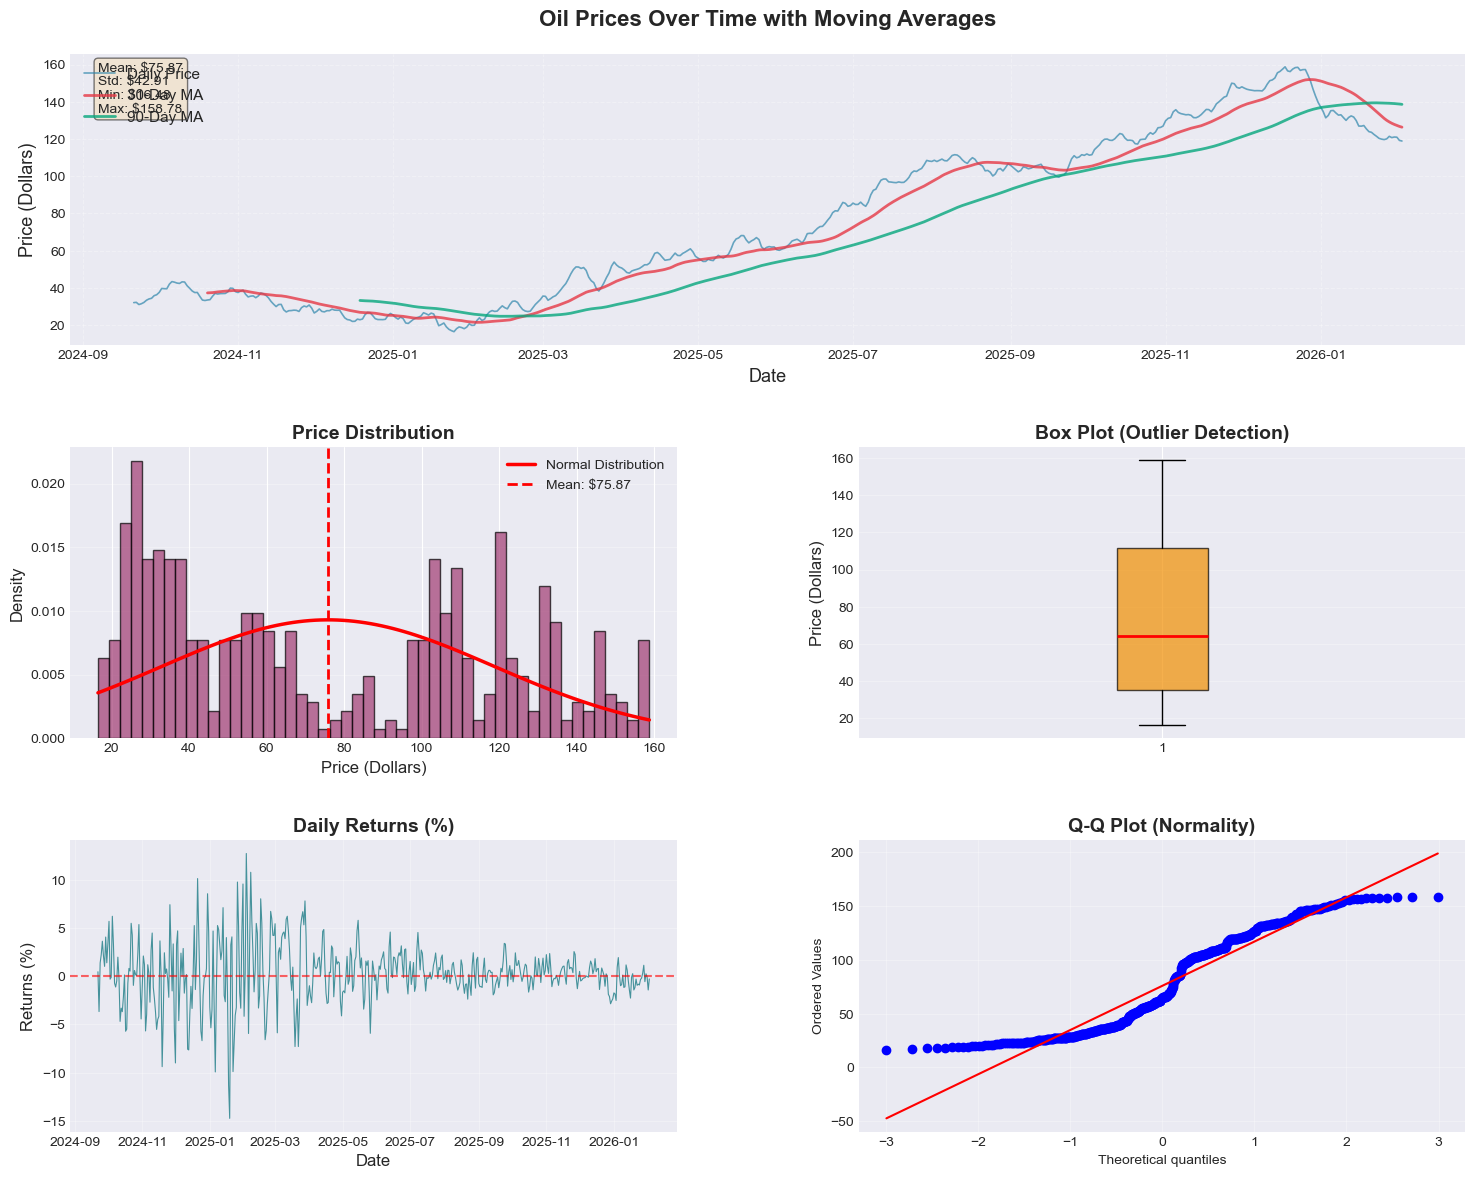


📊 Statistical Summary:
Mean: $75.8740
Median: $64.2900
Std Dev: $42.9124
Skewness: 0.2897
Kurtosis: -1.3453


In [96]:
# Perform EDA
perform_comprehensive_eda(df)

## 4️⃣ Stationarity Testing
1. **Augmented Dickey-Fuller (ADF) Test**
2. **Rolling Statistics Analysis**

In [98]:
def adf_test_manual(series, maxlag=None):
    """
    Manual implementation of Augmented Dickey-Fuller test.
    Tests H0: series has unit root (non-stationary).
    """
    y = np.array(series.dropna())
    n = len(y)
    
    if maxlag is None:
        maxlag = min(10, int(np.ceil(12 * (n / 100) ** 0.25)))
    
    dy = np.diff(y)
    y_lag = y[:-1]
    
    try:
        X = np.column_stack([y_lag, np.ones(len(y_lag))])
        y_reg = dy
        
        beta = np.linalg.lstsq(X, y_reg, rcond=None)[0]
        residuals = y_reg - X @ beta
        
        n_obs = len(y_reg)
        df = n_obs - len(beta)
        sigma2 = np.sum(residuals ** 2) / df
        var_beta = sigma2 * np.linalg.inv(X.T @ X)
        se_beta = np.sqrt(np.diag(var_beta))
        
        adf_stat = beta[0] / se_beta[0]
        
        critical_values = {
            '1%': -3.43,
            '5%': -2.86,
            '10%': -2.57
        }
        
        if adf_stat < critical_values['1%']:
            p_value = 0.01
        elif adf_stat < critical_values['5%']:
            p_value = 0.05
        elif adf_stat < critical_values['10%']:
            p_value = 0.10
        else:
            p_value = 0.20
        
        return {
            'adf_stat': adf_stat,
            'pvalue': p_value,
            'critical_values': critical_values,
            'is_stationary': p_value < 0.05
        }
    except:
        return {
            'adf_stat': 0.0,
            'pvalue': 1.0,
            'critical_values': {'1%': -3.43, '5%': -2.86, '10%': -2.57},
            'is_stationary': False
        }

In [99]:
def test_stationarity(df):
    """
    Comprehensive stationarity testing with visualization.
    """
    print('\n' + '='*80)
    print('STEP 3: STATIONARITY TESTS')
    print('='*80)
    
    series = df['price']
    
    # ADF test
    print('\n3.1 AUGMENTED DICKEY-FULLER TEST')
    print('-'*60)
    adf_result = adf_test_manual(series)
    
    print(f'ADF Statistic: {adf_result["adf_stat"]:.6f}')
    print(f'P-value: {adf_result["pvalue"]:.6f}')
    print('Critical Values:')
    for level, value in adf_result['critical_values'].items():
        comparison = '✓' if adf_result['adf_stat'] < value else '✗'
        print(f'  {level}: {value:.4f}  {comparison}')
    
    print(f'\n{'='*60}')
    if adf_result['is_stationary']:
        print('✅ CONCLUSION: Series is STATIONARY')
    else:
        print('⚠️ CONCLUSION: Series is NON-STATIONARY')
    print(f'{'='*60}')
    
    # Rolling statistics
    window = 30
    rolling_mean = series.rolling(window=window).mean()
    rolling_std = series.rolling(window=window).std()
    rolling_var = series.rolling(window=window).var()
    
    # Visualization
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    
    axes[0].plot(series.index, series, label='Original', 
                 color='#2E86AB', linewidth=1, alpha=0.7)
    axes[0].plot(rolling_mean.index, rolling_mean, 
                 label=f'{window}-Day Rolling Mean', 
                 color='#E63946', linewidth=2.5)
    axes[0].set_title('Original Series vs Rolling Mean', 
                      fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Price', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(rolling_std.index, rolling_std, 
                 color='#F77F00', linewidth=2)
    axes[1].set_title('Rolling Standard Deviation', 
                      fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Std Dev', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(rolling_var.index, rolling_var, 
                 color='#06A77D', linewidth=2)
    axes[2].set_title('Rolling Variance', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Date', fontsize=12)
    axes[2].set_ylabel('Variance', fontsize=12)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('stationarity_tests.png', dpi=300, bbox_inches='tight')
    print('\n✅ Rolling statistics plot saved')
    plt.show()
    
    return adf_result


STEP 3: STATIONARITY TESTS

3.1 AUGMENTED DICKEY-FULLER TEST
------------------------------------------------------------
ADF Statistic: -0.389744
P-value: 0.200000
Critical Values:
  1%: -3.4300  ✗
  5%: -2.8600  ✗
  10%: -2.5700  ✗

⚠️ CONCLUSION: Series is NON-STATIONARY

✅ Rolling statistics plot saved


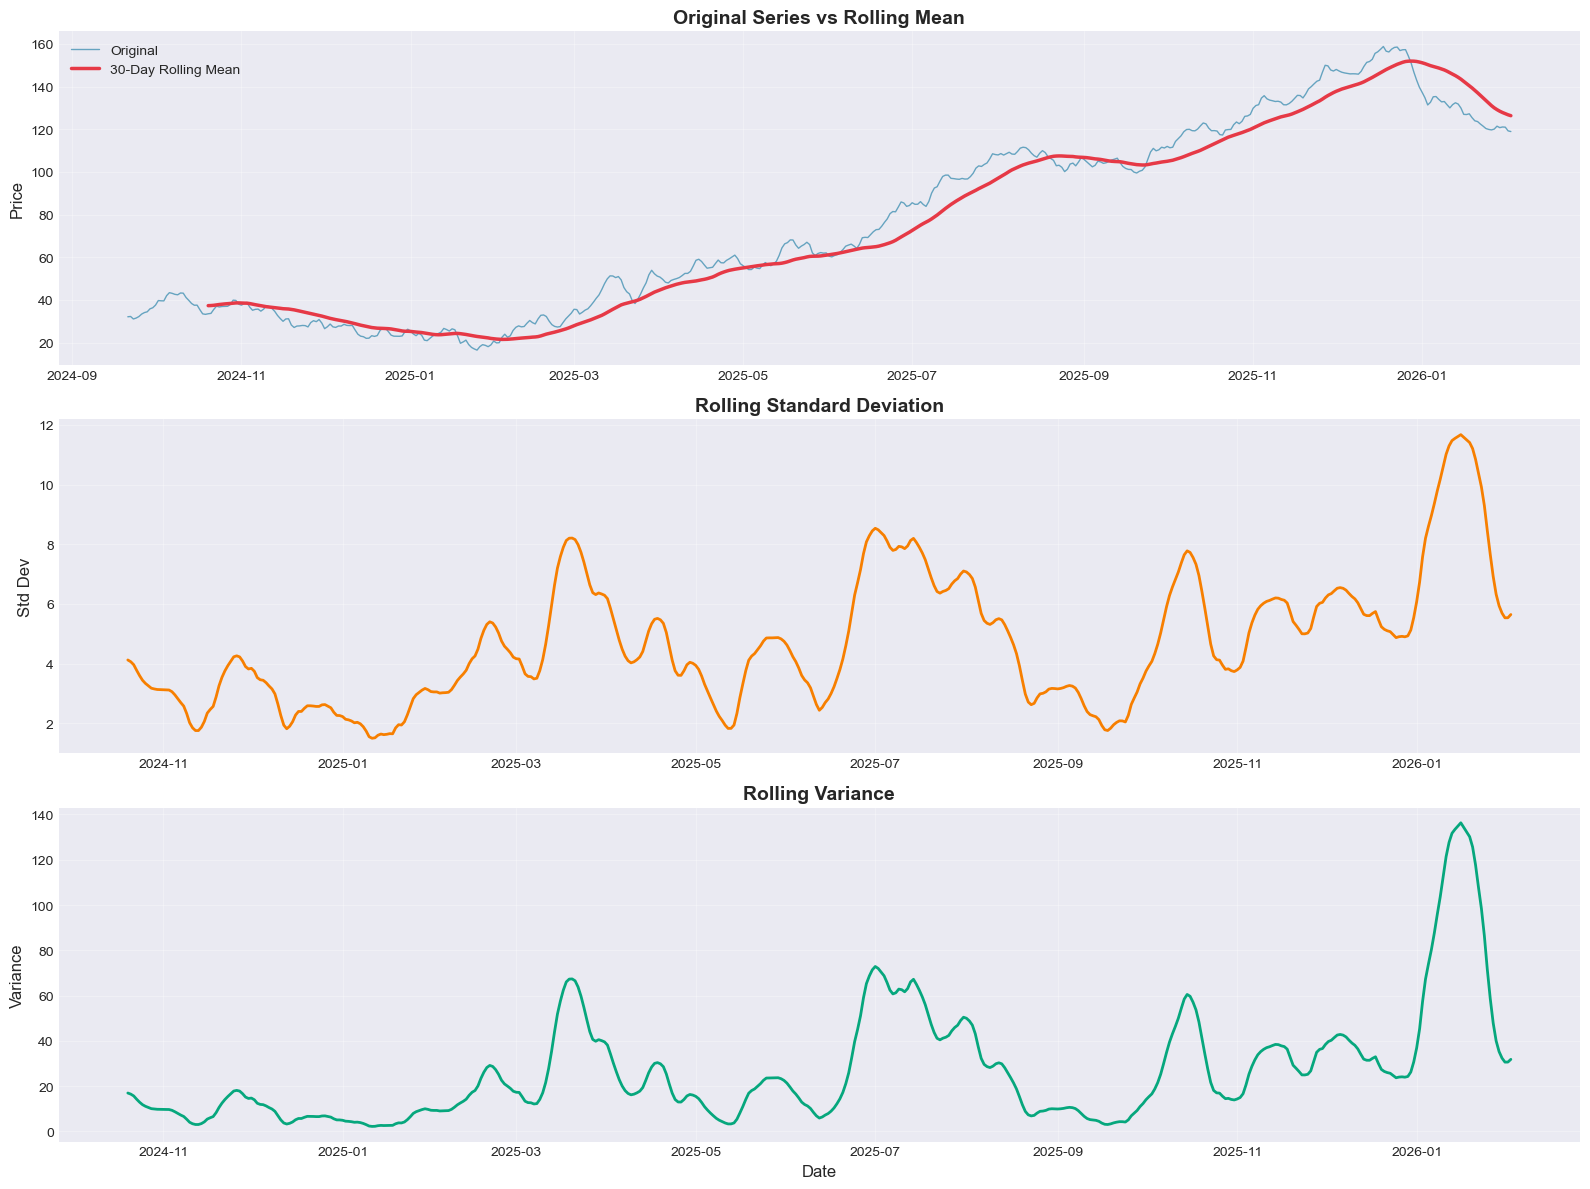

In [103]:
# Test stationarity
stationarity_result = test_stationarity(df)

## 5️⃣ Making the Series Stationary

If the series is non-stationary, apply differencing to achieve stationarity.

In [105]:
def make_stationary(df):
    """
    Transform non-stationary series to stationary using differencing.
    """
    print('\n' + '='*80)
    print('STEP 4: MAKING SERIES STATIONARY')
    print('='*80)
    
    df_work = df.copy()
    d = 0
    
    # Test original
    original_test = adf_test_manual(df_work['price'])
    
    if original_test['is_stationary']:
        print('\n✅ Series is already stationary!')
        return df_work, d
    
    # First differencing
    print('\nApplying FIRST DIFFERENCING...')
    df_work['price_diff1'] = df_work['price'].diff()
    diff1_test = adf_test_manual(df_work['price_diff1'].dropna())
    
    print(f'ADF Statistic: {diff1_test["adf_stat"]:.6f}')
    print(f'P-value: {diff1_test["pvalue"]:.6f}')
    
    d = 1
    
    if diff1_test['is_stationary']:
        print('\n✅ Series is stationary after first differencing (d=1)')
        return df_work[['price_diff1']].rename(columns={'price_diff1': 'price'}), d
    
    # Second differencing if needed
    print('\nApplying SECOND DIFFERENCING...')
    df_work['price_diff2'] = df_work['price_diff1'].diff()
    diff2_test = adf_test_manual(df_work['price_diff2'].dropna())
    
    d = 2
    print('\n✅ Differencing complete (d=2)')
    return df_work[['price_diff2']].rename(columns={'price_diff2': 'price'}), d

In [108]:
# Make stationary
if not stationarity_result['is_stationary']:
    df_stationary, d_order = make_stationary(df)
    working_series = df_stationary['price'].dropna()
    print(f'\n📊 Working with differenced series (d={d_order})')
else:
    working_series = df['price']
    d_order = 0
    print('\n📊 Working with original series (d=0)')


STEP 4: MAKING SERIES STATIONARY

Applying FIRST DIFFERENCING...
ADF Statistic: -12.807495
P-value: 0.010000

✅ Series is stationary after first differencing (d=1)

📊 Working with differenced series (d=1)


## 6️⃣ ACF and PACF Analysis

Analyze autocorrelation patterns to identify potential AR and MA orders.

In [111]:
def compute_acf(series, nlags=40):
    """Compute ACF manually."""
    series = np.array(series.dropna())
    mean = np.mean(series)
    c0 = np.sum((series - mean) ** 2) / len(series)
    
    acf_vals = [1.0]
    for lag in range(1, nlags + 1):
        if lag < len(series):
            c_lag = np.sum((series[:-lag] - mean) * (series[lag:] - mean)) / len(series)
            acf_vals.append(c_lag / c0)
        else:
            acf_vals.append(0)
    
    return np.array(acf_vals)

def compute_pacf(series, nlags=40):
    """Compute PACF using Yule-Walker equations."""
    acf_vals = compute_acf(series, nlags)
    pacf_vals = [1.0]
    
    for lag in range(1, nlags + 1):
        if lag == 1:
            pacf_vals.append(acf_vals[1])
        else:
            R = np.array([[acf_vals[abs(i-j)] for j in range(lag)] 
                         for i in range(lag)])
            r = acf_vals[1:lag+1]
            
            try:
                phi = np.linalg.solve(R, r)
                pacf_vals.append(phi[-1])
            except:
                pacf_vals.append(0)
    
    return np.array(pacf_vals)

def plot_acf_pacf(series, nlags=40):
    """Plot ACF and PACF."""
    print('\n' + '='*80)
    print('STEP 5: ACF AND PACF ANALYSIS')
    print('='*80)
    
    acf_vals = compute_acf(series, nlags)
    pacf_vals = compute_pacf(series, nlags)
    
    conf_int = 1.96 / np.sqrt(len(series))
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    lags = np.arange(len(acf_vals))
    
    # ACF
    axes[0].stem(lags, acf_vals, basefmt=' ', linefmt='#2E86AB', markerfmt='o')
    axes[0].axhline(y=conf_int, color='red', linestyle='--', linewidth=1.5)
    axes[0].axhline(y=-conf_int, color='red', linestyle='--', linewidth=1.5)
    axes[0].axhline(y=0, color='black', linewidth=0.8)
    axes[0].set_title('Autocorrelation Function (ACF)', 
                      fontsize=15, fontweight='bold')
    axes[0].set_xlabel('Lag', fontsize=13)
    axes[0].set_ylabel('ACF', fontsize=13)
    axes[0].grid(True, alpha=0.3)
    
    # PACF
    axes[1].stem(lags, pacf_vals, basefmt=' ', linefmt='#E63946', markerfmt='o')
    axes[1].axhline(y=conf_int, color='red', linestyle='--', linewidth=1.5)
    axes[1].axhline(y=-conf_int, color='red', linestyle='--', linewidth=1.5)
    axes[1].axhline(y=0, color='black', linewidth=0.8)
    axes[1].set_title('Partial Autocorrelation Function (PACF)', 
                      fontsize=15, fontweight='bold')
    axes[1].set_xlabel('Lag', fontsize=13)
    axes[1].set_ylabel('PACF', fontsize=13)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('acf_pacf_plots.png', dpi=300, bbox_inches='tight')
    print('\n✅ ACF/PACF plots saved')
    plt.show()
    
    # Suggest orders
    acf_significant = np.where(np.abs(acf_vals[1:]) > conf_int)[0] + 1
    pacf_significant = np.where(np.abs(pacf_vals[1:]) > conf_int)[0] + 1
    
    suggested_q = min(3, len(acf_significant)) if len(acf_significant) > 0 else 1
    suggested_p = min(3, len(pacf_significant)) if len(pacf_significant) > 0 else 1
    
    print(f'\n📊 Suggested starting values:')
    print(f'   p (AR order): {suggested_p}')
    print(f'   q (MA order): {suggested_q}')
    
    return suggested_p, suggested_q


STEP 5: ACF AND PACF ANALYSIS

✅ ACF/PACF plots saved


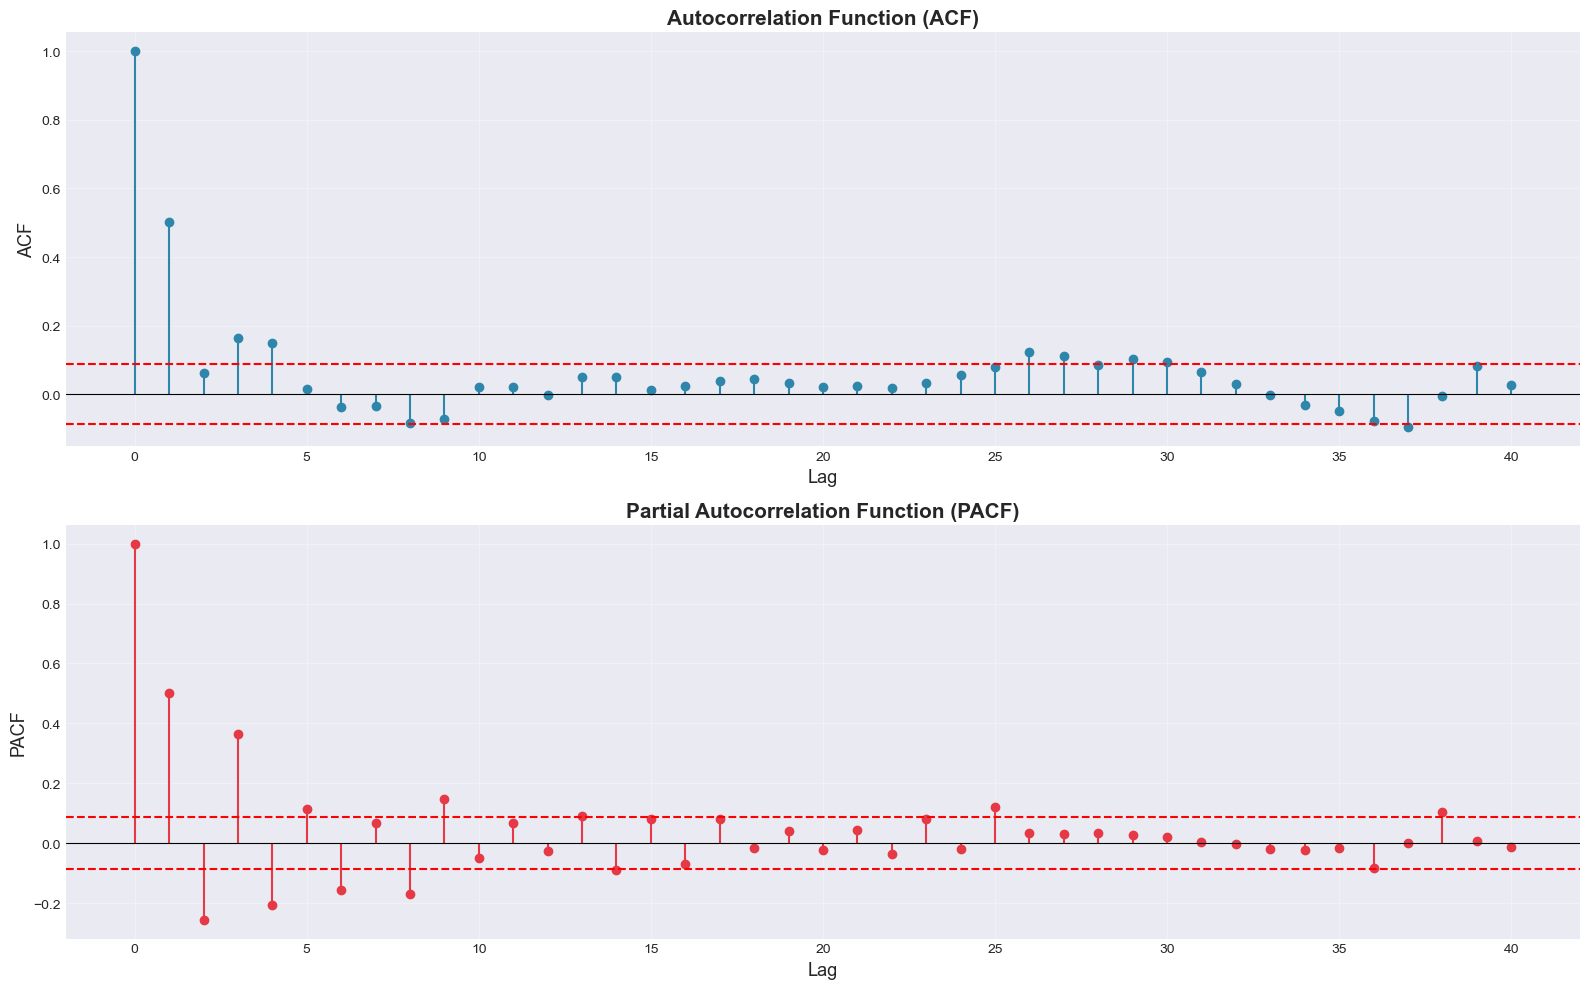


📊 Suggested starting values:
   p (AR order): 3
   q (MA order): 3


In [113]:
# Plot ACF and PACF
suggested_p, suggested_q = plot_acf_pacf(working_series)

## 7️⃣ ARIMA Model Implementation


In [120]:
class ARIMAModel:
    
    def __init__(self, order=(1, 0, 1)):
        self.p, self.d, self.q = order
        self.params = None
        self.sigma2 = None
        self.aic = None
        self.bic = None
        self.residuals = None
        self.fitted_values = None
        
    def difference(self, series, d):
        """Apply differencing of order d."""
        result = series.copy()
        for _ in range(d):
            result = np.diff(result)
        return result
    
    def log_likelihood(self, params, series):
        """Compute negative log-likelihood."""
        n = len(series)
        ar_params = params[:self.p] if self.p > 0 else np.array([])
        ma_params = params[self.p:self.p+self.q] if self.q > 0 else np.array([])
        
        residuals = np.zeros(n)
        fitted = np.zeros(n)
        
        for t in range(max(self.p, self.q), n):
            ar_part = sum(ar_params[i] * series[t-i-1] for i in range(self.p))
            ma_part = sum(ma_params[i] * residuals[t-i-1] for i in range(self.q))
            fitted[t] = ar_part + ma_part
            residuals[t] = series[t] - fitted[t]
        
        sigma2 = np.sum(residuals ** 2) / n
        if sigma2 <= 0:
            return 1e10
        
        ll = -0.5 * n * (np.log(2 * np.pi) + np.log(sigma2) + 1)
        return -ll
    
    def fit(self, series):
        """Fit model using Maximum Likelihood Estimation."""
        if isinstance(series, pd.Series):
            series = series.values
        
        if self.d > 0:
            series_diff = self.difference(series, self.d)
        else:
            series_diff = series
        
        n_params = self.p + self.q
        if n_params == 0:
            return False
        
        initial_params = np.random.randn(n_params) * 0.1
        
        try:
            result = minimize(
                self.log_likelihood, initial_params, args=(series_diff,),
                method='L-BFGS-B', options={'maxiter': 500, 'disp': False}
            )
            
            if not result.success:
                return False
            
            self.params = result.x
            
            # Compute fitted values
            n = len(series_diff)
            self.fitted_values = np.zeros(n)
            self.residuals = np.zeros(n)
            
            ar_params = self.params[:self.p] if self.p > 0 else np.array([])
            ma_params = self.params[self.p:] if self.q > 0 else np.array([])
            
            for t in range(max(self.p, self.q), n):
                ar_part = sum(ar_params[i] * series_diff[t-i-1] for i in range(self.p))
                ma_part = sum(ma_params[i] * self.residuals[t-i-1] for i in range(self.q))
                self.fitted_values[t] = ar_part + ma_part
                self.residuals[t] = series_diff[t] - self.fitted_values[t]
            
            # Information criteria
            self.sigma2 = np.sum(self.residuals ** 2) / n
            self.aic = n * np.log(self.sigma2) + 2 * n_params
            self.bic = n * np.log(self.sigma2) + n_params * np.log(n)
            
            return True
        except:
            return False
    
    def forecast(self, steps=1, series=None):
        """Generate multi-step ahead forecasts."""
        if self.params is None:
            raise ValueError('Model must be fitted first')
        
        forecasts = []
        ar_params = self.params[:self.p] if self.p > 0 else np.array([])
        
        if series is not None:
            last_values = series[-self.p:] if self.p > 0 else np.array([series[-1]])
        else:
            last_values = np.zeros(self.p) if self.p > 0 else np.array([0])
        
        for _ in range(steps):
            forecast = sum(ar_params[i] * last_values[-(i+1)] 
                          for i in range(min(self.p, len(last_values))))
            forecasts.append(forecast)
            last_values = np.append(last_values, forecast)[-self.p:]
        
        return np.array(forecasts)

print('✅ ARIMA Model class defined successfully')

✅ ARIMA Model class defined successfully


### Grid Search for Optimal ARIMA Parameters

In [123]:
def find_best_arima(series, p_range=range(0, 4), d_range=range(0, 3), q_range=range(0, 4)):
    """
    Grid search to find optimal ARIMA(p,d,q) using AIC.
    """
    print('\n' + '='*80)
    print('STEP 6: ARIMA MODEL SELECTION (GRID SEARCH)')
    print('='*80)
    
    total = len(p_range) * len(d_range) * len(q_range)
    print(f'\nParameter space:')
    print(f'  p (AR): {list(p_range)}')
    print(f'  d (Differencing): {list(d_range)}')
    print(f'  q (MA): {list(q_range)}')
    print(f'  Total combinations: {total}')
    
    results = []
    best_aic = np.inf
    best_params = None
    count = 0
    successful = 0
    
    print('\nFitting models...')
    for p in p_range:
        for d in d_range:
            for q in q_range:
                count += 1
                if p == 0 and q == 0:
                    continue
                
                if count % 10 == 0:
                    print(f'  Progress: {count}/{total} ({successful} successful)')
                
                try:
                    model = ARIMAModel(order=(p, d, q))
                    success = model.fit(series.values)
                    
                    if success and model.aic is not None:
                        successful += 1
                        results.append({
                            'p': p, 'd': d, 'q': q,
                            'AIC': model.aic, 'BIC': model.bic,
                            'Sigma2': model.sigma2
                        })
                        
                        if model.aic < best_aic:
                            best_aic = model.aic
                            best_params = (p, d, q)
                except:
                    continue
    
    if len(results) == 0:
        print('\n❌ No models converged successfully!')
        return None, None
    
    results_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
    
    print(f'\n✅ Grid search complete!')
    print(f'   Total tested: {count}')
    print(f'   Successful: {successful}')
    
    print('\n📊 Top 10 Models by AIC:')
    print(results_df.head(10).to_string(index=False))
    
    print(f'\n🏆 BEST MODEL SELECTED: ARIMA{best_params}')
    best_row = results_df.iloc[0]
    print(f'   AIC: {best_row["AIC"]:.4f}')
    print(f'   BIC: {best_row["BIC"]:.4f}')
    print(f'   Residual Variance: {best_row["Sigma2"]:.6f}')
    
    return best_params, results_df

In [125]:
# Execute grid search
best_params, model_comparison = find_best_arima(
    df['price'],
    p_range=range(0, 4),
    d_range=range(0, 3),
    q_range=range(0, 4)
)

if best_params is not None:
    model_comparison.to_csv('arima_model_comparison.csv', index=False)
    print('\n✅ Model comparison saved as "arima_model_comparison.csv"')


STEP 6: ARIMA MODEL SELECTION (GRID SEARCH)

Parameter space:
  p (AR): [0, 1, 2, 3]
  d (Differencing): [0, 1, 2]
  q (MA): [0, 1, 2, 3]
  Total combinations: 48

Fitting models...
  Progress: 10/48 (6 successful)
  Progress: 20/48 (15 successful)
  Progress: 30/48 (24 successful)
  Progress: 40/48 (34 successful)

✅ Grid search complete!
   Total tested: 48
   Successful: 42

📊 Top 10 Models by AIC:
 p  d  q     AIC     BIC  Sigma2
 3  1  3  8.3147 33.5903  0.9926
 2  1  3  9.5536 30.6166  0.9991
 3  1  2  9.8255 30.8886  0.9997
 3  1  1 10.8128 27.6633  1.0057
 3  2  2 14.8102 35.8632  1.0097
 0  1  2 15.9340 24.3592  1.0242
 3  2  3 16.0271 41.2907  1.0081
 0  2  2 16.3247 24.7459  1.0251
 1  1  3 16.6188 33.4693  1.0174
 1  2  3 17.6257 34.4681  1.0195

🏆 BEST MODEL SELECTED: ARIMA(3, 1, 3)
   AIC: 8.3147
   BIC: 33.5903
   Residual Variance: 0.992642

✅ Model comparison saved as "arima_model_comparison.csv"


## 8️⃣ ARIMA Model Evaluation

In [127]:
def evaluate_model_accuracy(fitted_model, actual_series, train_size=0.8):
    """
    Evaluate model on train-test split.
    """
    print('\n' + '='*80)
    print('STEP 7: MODEL EVALUATION')
    print('='*80)
    
    n = len(actual_series)
    train_n = int(n * train_size)
    
    train = actual_series.iloc[:train_n]
    test = actual_series.iloc[train_n:]
    
    print(f'\nData Split:')
    print(f'  Training: {len(train)} obs ({train_size*100:.0f}%)')
    print(f'  Testing: {len(test)} obs ({(1-train_size)*100:.0f}%)')
    print(f'  Train period: {train.index[0]} to {train.index[-1]}')
    print(f'  Test period: {test.index[0]} to {test.index[-1]}')
    
    # Get predictions
    in_sample_pred = fitted_model.fitted_values
    forecast_steps = len(test)
    forecast = fitted_model.forecast(steps=forecast_steps, series=train.values)
    
    # Align arrays for in-sample metrics
    n_fitted = len(in_sample_pred)
    n_actual = len(actual_series)
    
    if n_fitted < n_actual:
        offset = n_actual - n_fitted
        in_sample_actual_aligned = actual_series.values[offset:]
        in_sample_pred_aligned = in_sample_pred
        valid_dates = actual_series.index[offset:]
    else:
        in_sample_actual_aligned = actual_series.values
        in_sample_pred_aligned = in_sample_pred[:n_actual]
        valid_dates = actual_series.index
    
    valid_idx = ~np.isnan(in_sample_pred_aligned)
    in_sample_actual = in_sample_actual_aligned[valid_idx]
    in_sample_pred_valid = in_sample_pred_aligned[valid_idx]
    valid_dates = valid_dates[valid_idx]
    
    # Calculate metrics
    in_rmse = np.sqrt(mean_squared_error(in_sample_actual, in_sample_pred_valid))
    in_mae = mean_absolute_error(in_sample_actual, in_sample_pred_valid)
    in_mape = np.mean(np.abs((in_sample_actual - in_sample_pred_valid) / in_sample_actual)) * 100
    
    out_rmse = np.sqrt(mean_squared_error(test, forecast))
    out_mae = mean_absolute_error(test, forecast)
    out_mape = np.mean(np.abs((test.values - forecast) / test.values)) * 100
    
    print('\n📊 IN-SAMPLE PERFORMANCE (Training Data):')
    print(f'  RMSE: ${in_rmse:.4f}')
    print(f'  MAE:  ${in_mae:.4f}')
    print(f'  MAPE: {in_mape:.4f}%')
    
    print('\n📊 OUT-OF-SAMPLE PERFORMANCE (Test Data):')
    print(f'  RMSE: ${out_rmse:.4f}')
    print(f'  MAE:  ${out_mae:.4f}')
    print(f'  MAPE: {out_mape:.4f}%')
    
    # Visualization
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    # In-sample
    axes[0].plot(train.index, train, label='Actual (Train)', 
                 color='#2E86AB', linewidth=2)
    axes[0].plot(valid_dates, in_sample_pred_valid, label='Fitted', 
                 color='#E63946', linewidth=2, linestyle='--', alpha=0.8)
    axes[0].set_title('In-Sample Fit (Training Period)', 
                      fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Price ($)', fontsize=12)
    axes[0].legend(loc='best', fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    text_str = f"RMSE: ${in_rmse:.2f}\nMAE: ${in_mae:.2f}\nMAPE: {in_mape:.2f}%"
    axes[0].text(0.02, 0.97, text_str, transform=axes[0].transAxes,
                 fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    # Out-of-sample
    axes[1].plot(test.index, test, label='Actual (Test)', 
                 color='#2E86AB', linewidth=2)
    axes[1].plot(test.index, forecast, label='Forecast', 
                 color='#06A77D', linewidth=2, linestyle='--', alpha=0.8)
    axes[1].axvline(x=test.index[0], color='red', linestyle=':', 
                    linewidth=2, alpha=0.5, label='Forecast Start')
    axes[1].set_title('Out-of-Sample Forecast (Test Period)', 
                      fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Date', fontsize=12)
    axes[1].set_ylabel('Price ($)', fontsize=12)
    axes[1].legend(loc='best', fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    text_str = f"RMSE: ${out_rmse:.2f}\nMAE: ${out_mae:.2f}\nMAPE: {out_mape:.2f}%"
    axes[1].text(0.02, 0.97, text_str, transform=axes[1].transAxes,
                 fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
    
    plt.tight_layout()
    plt.savefig('model_evaluation.png', dpi=300, bbox_inches='tight')
    print('\n✅ Evaluation plot saved as "model_evaluation.png"')
    plt.show()
    
    return {
        'Model': f'ARIMA{fitted_model.p, fitted_model.d, fitted_model.q}',
        'RMSE': out_rmse,
        'MAE': out_mae,
        'MAPE': out_mape
    }


🔨 Fitting best model: ARIMA(3, 1, 3)

📈 Model Summary:
   Order (p,d,q): (3, 1, 3)
   AIC: 8.3147
   BIC: 33.5903
   Residual Variance (σ²): 0.992642

STEP 7: MODEL EVALUATION

Data Split:
  Training: 400 obs (80%)
  Testing: 100 obs (20%)
  Train period: 2024-09-21 00:00:00 to 2025-10-25 00:00:00
  Test period: 2025-10-26 00:00:00 to 2026-02-02 00:00:00

📊 IN-SAMPLE PERFORMANCE (Training Data):
  RMSE: $87.1228
  MAE:  $75.8552
  MAPE: 99.8929%

📊 OUT-OF-SAMPLE PERFORMANCE (Test Data):
  RMSE: $137.6363
  MAE:  $136.9193
  MAPE: 99.5176%

✅ Evaluation plot saved as "model_evaluation.png"


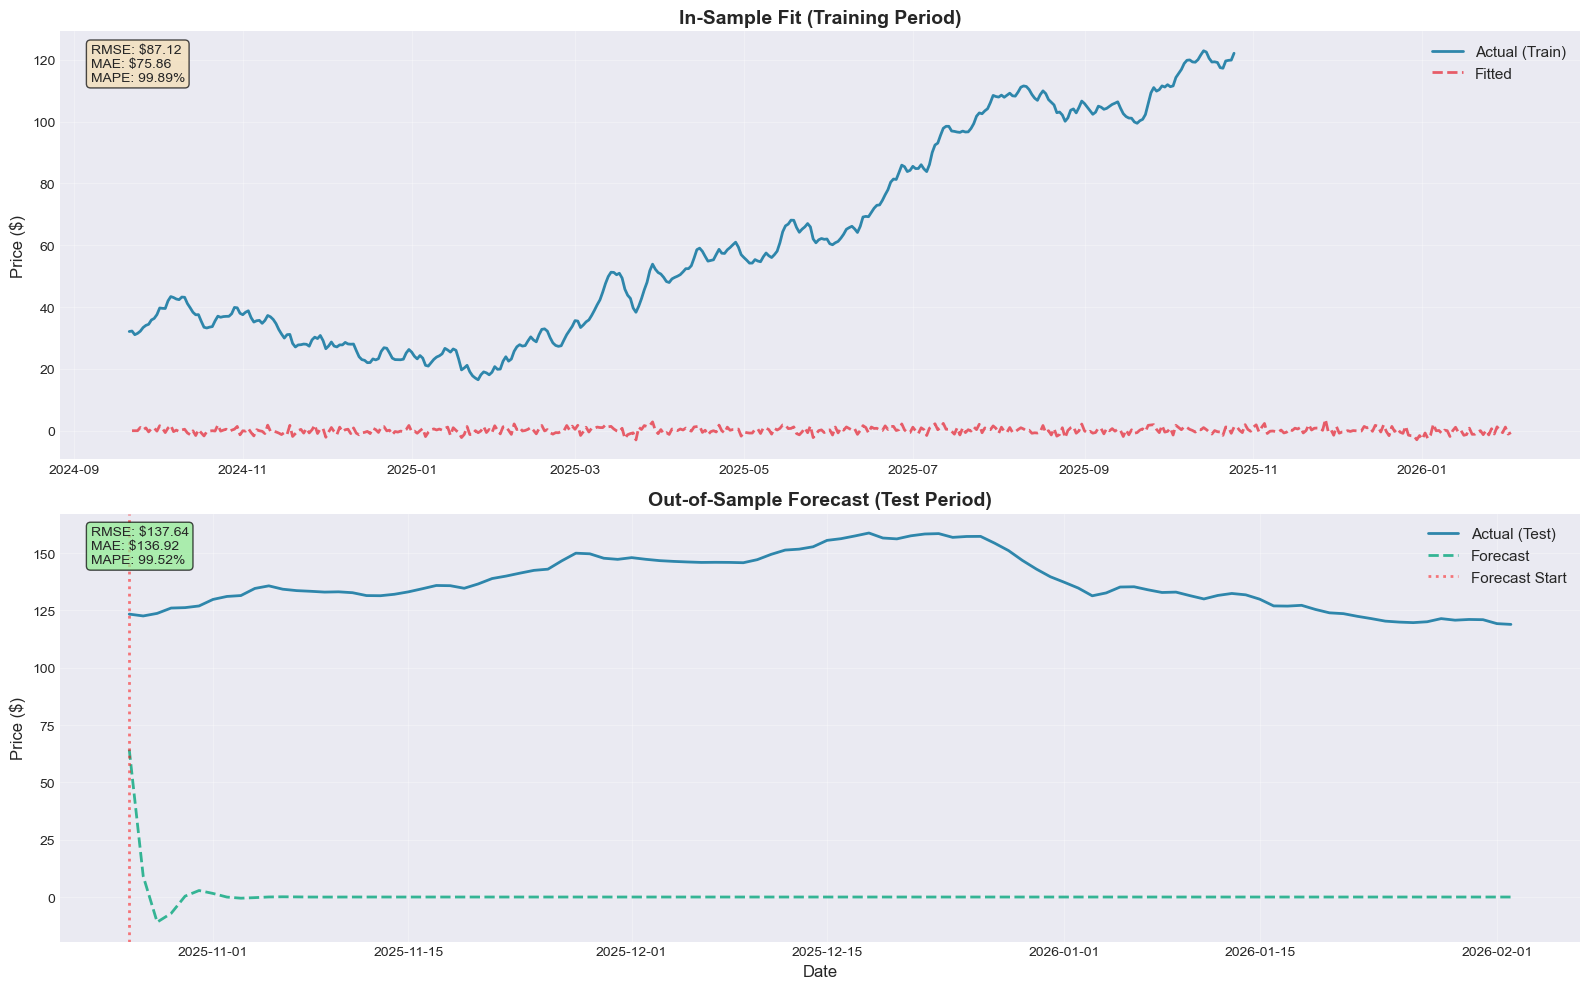

In [128]:
if best_params is not None:
    # Fit best model
    print(f'\n🔨 Fitting best model: ARIMA{best_params}')
    arima_model = ARIMAModel(order=best_params)
    arima_model.fit(df['price'])
    
    print(f'\n📈 Model Summary:')
    print(f'   Order (p,d,q): {best_params}')
    print(f'   AIC: {arima_model.aic:.4f}')
    print(f'   BIC: {arima_model.bic:.4f}')
    print(f'   Residual Variance (σ²): {arima_model.sigma2:.6f}')
    
    # Evaluate
    arima_metrics = evaluate_model_accuracy(arima_model, df['price'])
else:
    print('\n⚠️ Skipping evaluation - no model was fitted')

### Generate 24-Month ARIMA Forecast

In [130]:
def forecast_future(fitted_model, original_series, steps=24):
    """
    Generate 24-month ahead forecasts with confidence intervals.
    """
    print('\n' + '='*80)
    print(f'STEP 8: FORECASTING {steps} PERIODS AHEAD')
    print('='*80)
    
    # Generate forecast
    forecast_values = fitted_model.forecast(steps=steps, series=original_series.values)
    
    # Create future dates
    last_date = original_series.index[-1]
    future_dates = pd.date_range(start=last_date + timedelta(days=1), 
                                  periods=steps, freq='D')
    
    # Confidence intervals
    std_error = np.std(fitted_model.residuals)
    ci_multiplier = np.sqrt(np.arange(1, steps + 1))
    lower_ci = forecast_values - 1.96 * std_error * ci_multiplier
    upper_ci = forecast_values + 1.96 * std_error * ci_multiplier
    
    forecast_df = pd.DataFrame({
        'Date': future_dates,
        'Forecast': forecast_values,
        'Lower_CI_95': lower_ci,
        'Upper_CI_95': upper_ci,
        'Std_Error': std_error * ci_multiplier
    })
    forecast_df.set_index('Date', inplace=True)
    
    print('\n📊 Forecast Summary:')
    print('\nFirst 10 periods:')
    print(forecast_df.head(10))
    print('\nLast 10 periods:')
    print(forecast_df.tail(10))
    
    print(f'\n📊 Forecast Statistics:')
    print(f'  Mean Forecast: ${forecast_df["Forecast"].mean():.2f}')
    print(f'  Min Forecast: ${forecast_df["Forecast"].min():.2f}')
    print(f'  Max Forecast: ${forecast_df["Forecast"].max():.2f}')
    print(f'  Std Dev: ${forecast_df["Forecast"].std():.2f}')
    
    # Visualization
    plt.figure(figsize=(16, 8))
    
    plt.plot(original_series.index, original_series, 
             label='Historical Data', color='#2E86AB', linewidth=2)
    plt.plot(forecast_df.index, forecast_df['Forecast'], 
             label=f'{steps}-Period Forecast', color='#E63946', 
             linewidth=2, linestyle='--')
    plt.fill_between(forecast_df.index, 
                     forecast_df['Lower_CI_95'], 
                     forecast_df['Upper_CI_95'], 
                     alpha=0.3, color='#E63946', 
                     label='95% Confidence Interval')
    plt.axvline(x=last_date, color='black', linestyle=':', 
                linewidth=2, label='Forecast Start')
    
    plt.title(f'ARIMA{fitted_model.p, fitted_model.d, fitted_model.q}: 24-Month Forecast', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price (Dollars)', fontsize=12)
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('arima_forecast_24months.png', dpi=300, bbox_inches='tight')
    print('\n✅ Forecast plot saved as "arima_forecast_24months.png"')
    plt.show()
    
    return forecast_df


STEP 8: FORECASTING 24 PERIODS AHEAD

📊 Forecast Summary:

First 10 periods:
            Forecast  Lower_CI_95  Upper_CI_95  Std_Error
Date                                                     
2026-02-03   61.7969      59.8487      63.7450     0.9939
2026-02-04    8.4312       5.6761      11.1863     1.4056
2026-02-05  -10.6448     -14.0191      -7.2705     1.7216
2026-02-06   -6.7965     -10.6928      -2.9002     1.9879
2026-02-07    0.4405      -3.9157       4.7966     2.2225
2026-02-08    2.7504      -2.0216       7.5223     2.4347
2026-02-09    1.4851      -3.6692       6.6393     2.6297
2026-02-10   -0.0411      -5.5512       5.4690     2.8113
2026-02-11   -0.4967      -6.3411       5.3477     2.9818
2026-02-12   -0.2569      -6.4174       5.9037     3.1431

Last 10 periods:
              Forecast  Lower_CI_95  Upper_CI_95  Std_Error
Date                                                       
2026-02-17 -1.8749e-02      -7.5638       7.5263     3.8495
2026-02-18 -8.4660e-03      

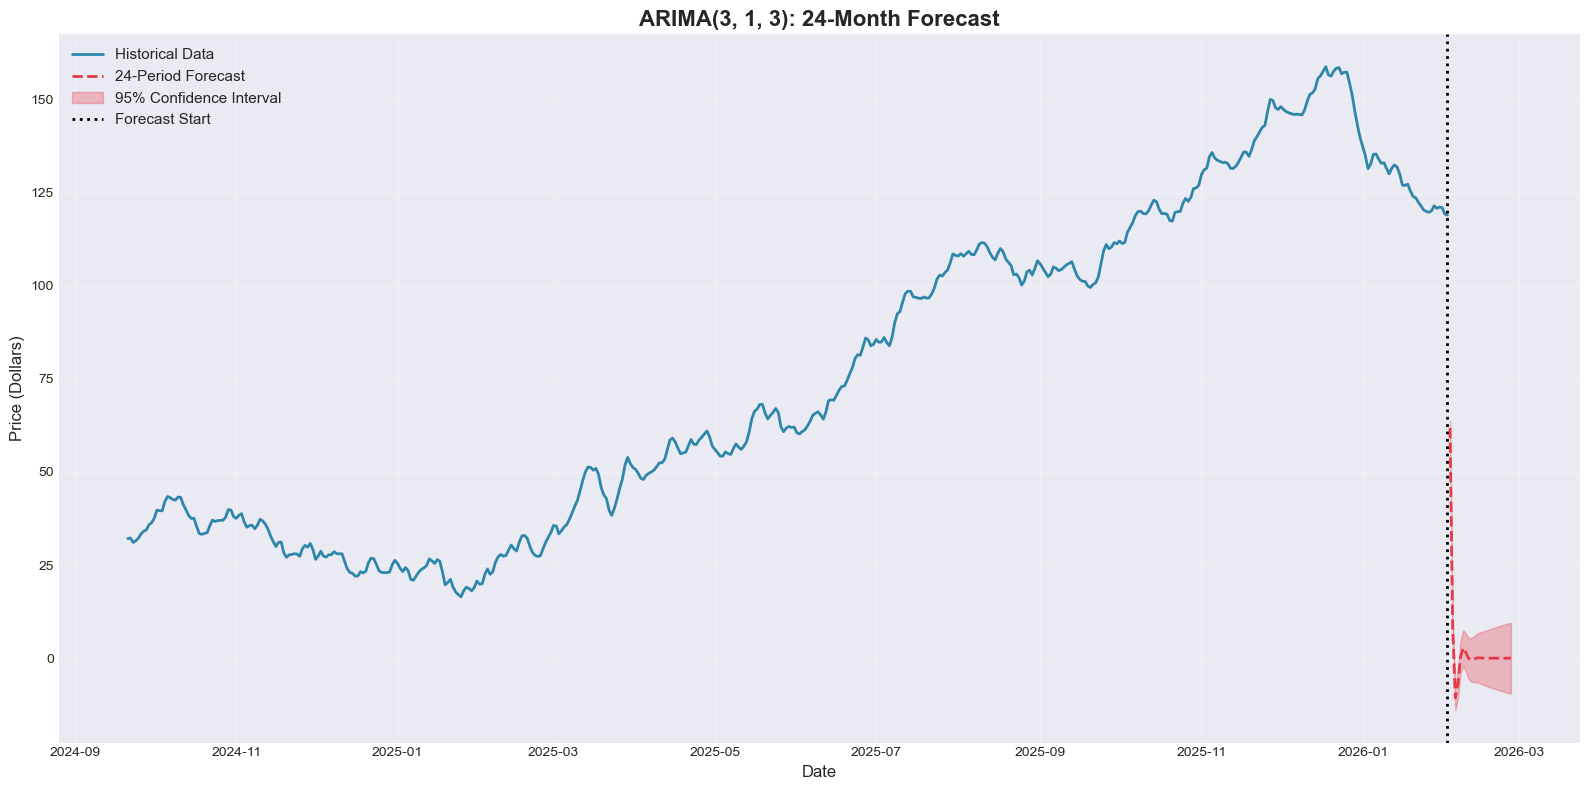


✅ ARIMA results saved!
   - arima_forecast_results.csv
   - arima_metrics.csv


In [131]:
if best_params is not None:
    # Generate forecast
    arima_forecast = forecast_future(arima_model, df['price'], steps=24)
    
    # Save results
    arima_forecast.to_csv('arima_forecast_results.csv')
    pd.DataFrame([arima_metrics]).to_csv('arima_metrics.csv', index=False)
    
    print('\n✅ ARIMA results saved!')
    print('   - arima_forecast_results.csv')
    print('   - arima_metrics.csv')
else:
    print('\n⚠️ Skipping forecast - no model was fitted')

---

#  PART 2: PROPHET MODEL (ALTERNATIVE APPROACH)

---

## 9️⃣ Prophet Model Implementation

In [133]:
class SimpleProphet:
    """
    Simplified Prophet-style forecasting model.
    
    Model decomposition:
    y(t) = g(t) + s(t) + ε_t
    
    where:
      g(t) = trend component (piecewise linear)
      s(t) = seasonal component (Fourier series)
      ε_t = error term (white noise)
    """
    
    def __init__(self, yearly_seasonality=True, weekly_seasonality=True,
                 changepoint_prior_scale=0.05, seasonality_prior_scale=10.0):
        self.yearly_seasonality = yearly_seasonality
        self.weekly_seasonality = weekly_seasonality
        self.changepoint_prior_scale = changepoint_prior_scale
        self.seasonality_prior_scale = seasonality_prior_scale
        
        self.trend_params = None
        self.seasonal_params = None
        self.residual_std = None
        self.df_train = None
        
    def _linear_trend(self, t, k, m):
        """Compute linear trend: k*t + m"""
        return k * t + m
    
    def _fourier_series(self, t, period, n_order):
        """
        Compute Fourier series features for seasonality.
        
        Returns matrix with columns:
        [sin(2πt/P), cos(2πt/P), sin(4πt/P), cos(4πt/P), ...]
        """
        features = np.zeros((len(t), 2 * n_order))
        for i in range(n_order):
            features[:, 2*i] = np.sin(2 * np.pi * (i + 1) * t / period)
            features[:, 2*i + 1] = np.cos(2 * np.pi * (i + 1) * t / period)
        return features
    
    def fit(self, df):
        """
        Fit Prophet model to DataFrame with 'ds' (date) and 'y' (value) columns.
        """
        y = df['y'].values
        n = len(y)
        t = np.arange(n)
        
        # Step 1: Fit linear trend using least squares
        A_trend = np.column_stack([t, np.ones(n)])
        trend_coef = np.linalg.lstsq(A_trend, y, rcond=None)[0]
        self.trend_params = {'k': trend_coef[0], 'm': trend_coef[1]}
        
        # Step 2: Detrend the series
        trend = self._linear_trend(t, trend_coef[0], trend_coef[1])
        detrended = y - trend
        
        # Step 3: Fit seasonal components
        self.seasonal_params = {}
        seasonal_component = np.zeros(n)
        
        # Yearly seasonality
        if self.yearly_seasonality and n > 365:
            fourier_yearly = self._fourier_series(t, period=365.25, n_order=10)
            yearly_coef = np.linalg.lstsq(fourier_yearly, detrended, rcond=None)[0]
            self.seasonal_params['yearly'] = yearly_coef
            yearly_seasonal = fourier_yearly @ yearly_coef
            seasonal_component += yearly_seasonal * (self.seasonality_prior_scale / 10)
            detrended -= yearly_seasonal * (self.seasonality_prior_scale / 10)
        
        # Weekly seasonality
        if self.weekly_seasonality and n > 14:
            fourier_weekly = self._fourier_series(t, period=7, n_order=3)
            weekly_coef = np.linalg.lstsq(fourier_weekly, detrended, rcond=None)[0]
            self.seasonal_params['weekly'] = weekly_coef
            weekly_seasonal = fourier_weekly @ weekly_coef
            seasonal_component += weekly_seasonal * (self.seasonality_prior_scale / 10)
        
        # Step 4: Compute residuals and standard deviation
        fitted = trend + seasonal_component
        residuals = y - fitted
        self.residual_std = np.std(residuals)
        
        # Store training data
        self.df_train = df.copy()
        self.start_date = df['ds'].iloc[0]
        
        return self
    
    def predict(self, periods):
        """
        Generate forecasts for specified number of future periods.
        
        Returns DataFrame with:
        - ds: forecast dates
        - yhat: point forecast
        - yhat_lower/yhat_upper: 95% confidence intervals
        - trend: trend component
        - seasonal: seasonal component
        """
        n_train = len(self.df_train)
        t_future = np.arange(n_train, n_train + periods)
        
        # Generate future dates
        last_date = self.df_train['ds'].iloc[-1]
        future_dates = pd.date_range(start=last_date + timedelta(days=1),
                                     periods=periods, freq='D')
        
        # Compute trend
        trend = self._linear_trend(t_future, 
                                   self.trend_params['k'],
                                   self.trend_params['m'])
        
        # Compute seasonal components
        seasonal = np.zeros(periods)
        
        if self.yearly_seasonality and 'yearly' in self.seasonal_params:
            fourier_yearly = self._fourier_series(t_future, period=365.25, n_order=10)
            yearly = fourier_yearly @ self.seasonal_params['yearly']
            seasonal += yearly * (self.seasonality_prior_scale / 10)
        
        if self.weekly_seasonality and 'weekly' in self.seasonal_params:
            fourier_weekly = self._fourier_series(t_future, period=7, n_order=3)
            weekly = fourier_weekly @ self.seasonal_params['weekly']
            seasonal += weekly * (self.seasonality_prior_scale / 10)
        
        # Combine components
        yhat = trend + seasonal
        
        # Compute confidence intervals
        # Widening with forecast horizon
        ci_width = self.residual_std * np.sqrt(np.arange(1, periods + 1))
        yhat_lower = yhat - 1.96 * ci_width
        yhat_upper = yhat + 1.96 * ci_width
        
        # Create forecast DataFrame
        forecast_df = pd.DataFrame({
            'ds': future_dates,
            'yhat': yhat,
            'yhat_lower': yhat_lower,
            'yhat_upper': yhat_upper,
            'trend': trend,
            'seasonal': seasonal
        })
        
        return forecast_df

print('✅ Prophet Model class defined successfully')

✅ Prophet Model class defined successfully


### Hyperparameter Tuning

Optimize Prophet hyperparameters using grid search with time series cross-validation.

In [135]:
def tune_prophet_hyperparameters(df, param_grid):
    """
    Tune Prophet hyperparameters using validation set.
    """
    print('\n' + '='*80)
    print('STEP 9: PROPHET HYPERPARAMETER TUNING')
    print('='*80)
    
    # Generate all parameter combinations
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    param_combinations = list(product(*param_values))
    
    print(f'\nParameter grid:')
    for name, values in param_grid.items():
        print(f'  {name}: {values}')
    print(f'  Total combinations: {len(param_combinations)}')
    
    # Split data for validation
    train_size = int(len(df) * 0.8)
    train_df = df.iloc[:train_size]
    val_df = df.iloc[train_size:]
    
    print(f'\nValidation split:')
    print(f'  Train: {len(train_df)} obs')
    print(f'  Validation: {len(val_df)} obs')
    
    results = []
    best_rmse = np.inf
    best_params = None
    
    print('\nTesting parameter combinations...')
    for i, params in enumerate(param_combinations):
        param_dict = dict(zip(param_names, params))
        
        try:
            # Fit model
            model = SimpleProphet(**param_dict)
            model.fit(train_df)
            
            # Predict validation period
            forecast = model.predict(len(val_df))
            
            # Calculate RMSE
            rmse = np.sqrt(mean_squared_error(val_df['y'].values, forecast['yhat'].values))
            
            # Store results
            results.append({**param_dict, 'RMSE': rmse})
            
            # Update best
            if rmse < best_rmse:
                best_rmse = rmse
                best_params = param_dict
            
            print(f'  [{i+1}/{len(param_combinations)}] RMSE: {rmse:.4f} | Best: {best_rmse:.4f}')
            
        except Exception as e:
            print(f'  [{i+1}/{len(param_combinations)}] FAILED')
            continue
    
    # Create results DataFrame
    results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
    
    print(f'\n✅ Tuning complete!')
    print('\n📊 All results (sorted by RMSE):')
    print(results_df.to_string(index=False))
    
    print(f'\n BEST PARAMETERS:')
    for key, value in best_params.items():
        print(f'   {key}: {value}')
    print(f'   Validation RMSE: ${best_rmse:.4f}')
    
    return best_params, results_df

In [136]:
# Prepare data for Prophet
prophet_df = pd.DataFrame({
    'ds': df.index,
    'y': df['price'].values
})

print('📊 Prophet data prepared:')
print(f'   Shape: {prophet_df.shape}')
print(f'   Date range: {prophet_df["ds"].min()} to {prophet_df["ds"].max()}')
print('\nFirst 5 rows:')
print(prophet_df.head())

📊 Prophet data prepared:
   Shape: (500, 2)
   Date range: 2024-09-21 00:00:00 to 2026-02-02 00:00:00

First 5 rows:
          ds      y
0 2024-09-21  32.10
1 2024-09-22  32.25
2 2024-09-23  31.07
3 2024-09-24  31.50
4 2024-09-25  32.21


In [139]:
# Define hyperparameter grid
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1],
    'seasonality_prior_scale': [1.0, 5.0, 10.0],
    'yearly_seasonality': [True],
    'weekly_seasonality': [True]
}

# Tune hyperparameters
best_prophet_params, tuning_results = tune_prophet_hyperparameters(prophet_df, param_grid)

# Save tuning results
tuning_results.to_csv('prophet_hyperparameter_tuning.csv', index=False)
print('\n✅ Tuning results saved as "prophet_hyperparameter_tuning.csv"')


STEP 9: PROPHET HYPERPARAMETER TUNING

Parameter grid:
  changepoint_prior_scale: [0.01, 0.05, 0.1]
  seasonality_prior_scale: [1.0, 5.0, 10.0]
  yearly_seasonality: [True]
  weekly_seasonality: [True]
  Total combinations: 9

Validation split:
  Train: 400 obs
  Validation: 100 obs

Testing parameter combinations...
  [1/9] RMSE: 19.0542 | Best: 19.0542
  [2/9] RMSE: 18.2359 | Best: 18.2359
  [3/9] RMSE: 19.0290 | Best: 18.2359
  [4/9] RMSE: 19.0542 | Best: 18.2359
  [5/9] RMSE: 18.2359 | Best: 18.2359
  [6/9] RMSE: 19.0290 | Best: 18.2359
  [7/9] RMSE: 19.0542 | Best: 18.2359
  [8/9] RMSE: 18.2359 | Best: 18.2359
  [9/9] RMSE: 19.0290 | Best: 18.2359

✅ Tuning complete!

📊 All results (sorted by RMSE):
 changepoint_prior_scale  seasonality_prior_scale  yearly_seasonality  weekly_seasonality    RMSE
                    0.01                      5.0                True                True 18.2359
                    0.05                      5.0                True                True

### Train Final Prophet Model with Best Parameters

In [141]:
print('\n' + '='*80)
print('STEP 10: TRAINING FINAL PROPHET MODEL')
print('='*80)

# Train final model with optimized parameters
prophet_model = SimpleProphet(**best_prophet_params)
prophet_model.fit(prophet_df)

print('\n✅ Prophet model trained successfully')
print(f'\nModel configuration:')
for key, value in best_prophet_params.items():
    print(f'  {key}: {value}')

print(f'\nModel components:')
print(f'  Trend params: k={prophet_model.trend_params["k"]:.6f}, m={prophet_model.trend_params["m"]:.2f}')
print(f'  Residual std: {prophet_model.residual_std:.4f}')
print(f'  Seasonal components: {list(prophet_model.seasonal_params.keys())}')


STEP 10: TRAINING FINAL PROPHET MODEL

✅ Prophet model trained successfully

Model configuration:
  changepoint_prior_scale: 0.01
  seasonality_prior_scale: 5.0
  yearly_seasonality: True
  weekly_seasonality: True

Model components:
  Trend params: k=0.279959, m=6.02
  Residual std: 9.5873
  Seasonal components: ['yearly', 'weekly']


### 9.3 Evaluate Prophet Model Performance

In [151]:
print('\n' + '='*80)
print('STEP 11: PROPHET MODEL EVALUATION')
print('='*80)

# Split for evaluation (same 80-20 as ARIMA)
train_size = int(len(prophet_df) * 0.8)
train_df = prophet_df.iloc[:train_size]
test_df = prophet_df.iloc[train_size:]

print(f'\nEvaluation split:')
print(f'  Training: {len(train_df)} obs')
print(f'  Testing: {len(test_df)} obs')

# Fit on training data
model_eval = SimpleProphet(**best_prophet_params)
model_eval.fit(train_df)

# Predict test period
test_forecast = model_eval.predict(len(test_df))

# Calculate metrics
prophet_rmse = np.sqrt(mean_squared_error(test_df['y'].values, test_forecast['yhat'].values))
prophet_mae = mean_absolute_error(test_df['y'].values, test_forecast['yhat'].values)
prophet_mape = np.mean(np.abs((test_df['y'].values - test_forecast['yhat'].values) / 
                              test_df['y'].values)) * 100

print('\n📊 TEST SET PERFORMANCE:')
print(f'  RMSE: ${prophet_rmse:.4f}')
print(f'  MAE:  ${prophet_mae:.4f}')
print(f'  MAPE: {prophet_mape:.2f}%')

prophet_metrics = {
    'Model': 'Prophet',
    'RMSE': prophet_rmse,
    'MAE': prophet_mae,
    'MAPE': prophet_mape
}

# Save metrics
pd.DataFrame([prophet_metrics]).to_csv('prophet_metrics.csv', index=False)
print('\n✅ Prophet metrics saved')


STEP 11: PROPHET MODEL EVALUATION

Evaluation split:
  Training: 400 obs
  Testing: 100 obs

📊 TEST SET PERFORMANCE:
  RMSE: $18.2359
  MAE:  $15.0122
  MAPE: 10.40%

✅ Prophet metrics saved


### Generate 24-Month Prophet Forecast with Component Decomposition

In [154]:
print('\n' + '='*80)
print('STEP 12: PROPHET 24-MONTH FORECAST')
print('='*80)

# Generate forecast
prophet_forecast = prophet_model.predict(24)

print('\n📊 Forecast Summary:')
print('\nFirst 10 periods:')
print(prophet_forecast.head(10))
print('\nLast 10 periods:')
print(prophet_forecast.tail(10))

print(f'\n📊 Forecast Statistics:')
print(f'  Mean Forecast: ${prophet_forecast["yhat"].mean():.2f}')
print(f'  Min Forecast: ${prophet_forecast["yhat"].min():.2f}')
print(f'  Max Forecast: ${prophet_forecast["yhat"].max():.2f}')
print(f'  Mean Trend: ${prophet_forecast["trend"].mean():.2f}')
print(f'  Mean Seasonal: ${prophet_forecast["seasonal"].mean():.2f}')


STEP 12: PROPHET 24-MONTH FORECAST

📊 Forecast Summary:

First 10 periods:
          ds      yhat  yhat_lower  yhat_upper     trend  seasonal
0 2026-02-03  135.8234    117.0323    154.6144  146.0036  -10.1803
1 2026-02-04  136.0788    109.5042    162.6533  146.2836  -10.2048
2 2026-02-05  136.3270    103.7800    168.8741  146.5635  -10.2365
3 2026-02-06  136.6103     99.0282    174.1924  146.8435  -10.2332
4 2026-02-07  137.0741     95.0560    179.0921  147.1235  -10.0494
5 2026-02-08  137.3728     91.3443    183.4012  147.4034  -10.0306
6 2026-02-09  137.7158     87.9993    187.4322  147.6834   -9.9676
7 2026-02-10  138.2086     85.0595    191.3577  147.9633   -9.7547
8 2026-02-11  138.5506     82.1775    194.9238  148.2433   -9.6927
9 2026-02-12  138.8853     79.4628    198.3078  148.5232   -9.6380

Last 10 periods:
           ds      yhat  yhat_lower  yhat_upper     trend  seasonal
14 2026-02-17  141.1888     68.4114    213.9661  149.9230   -8.7343
15 2026-02-18  141.6093     66.44


✅ Prophet forecast plot saved as "prophet_forecast_24months.png"


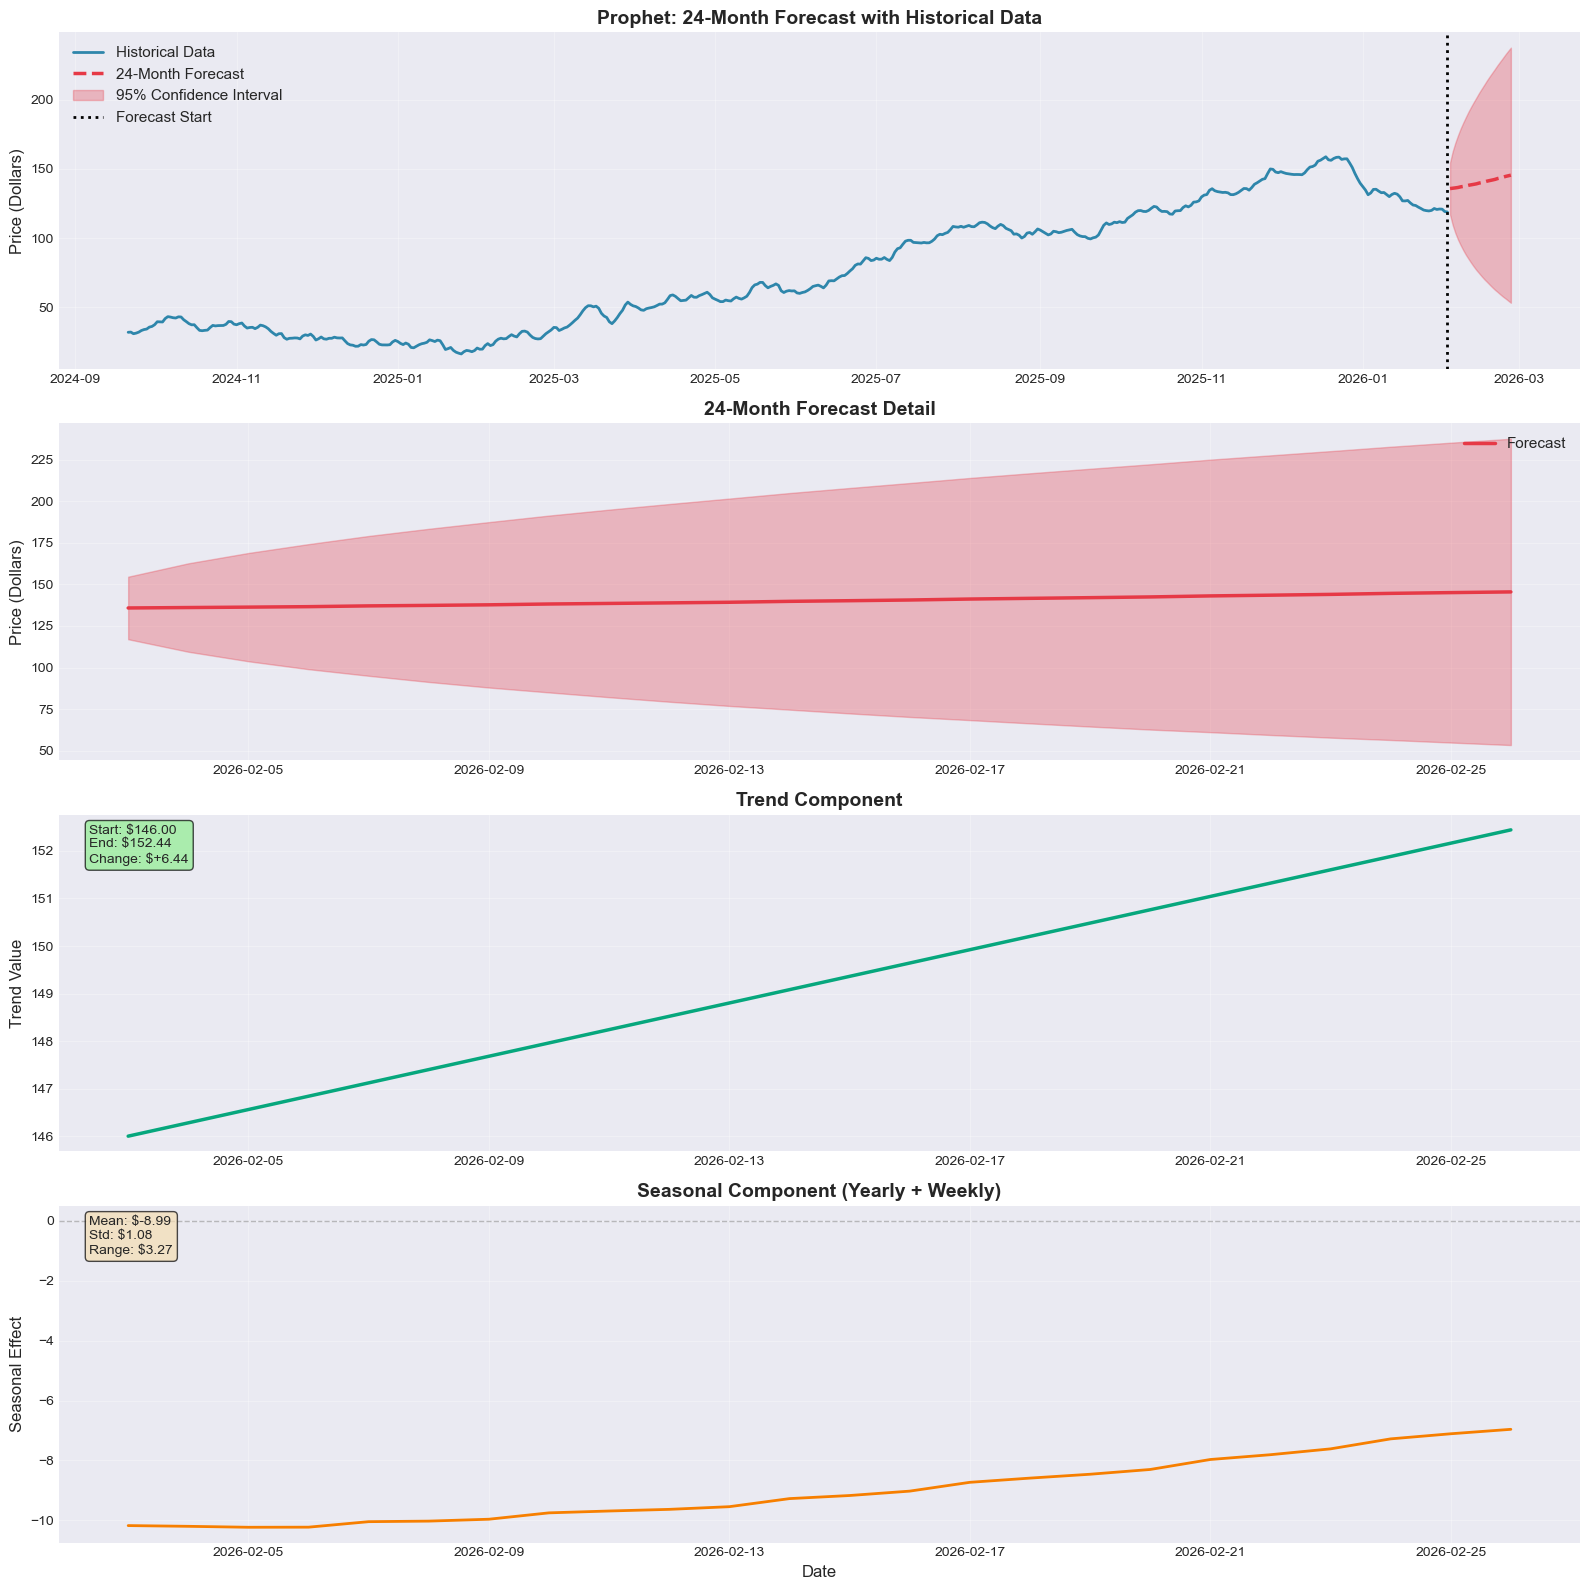

✅ Prophet forecast saved as "prophet_forecast_results.csv"


In [156]:
# Create comprehensive visualization
fig, axes = plt.subplots(4, 1, figsize=(16, 16))

# 1. Overall forecast
axes[0].plot(prophet_df['ds'], prophet_df['y'], 
             label='Historical Data', color='#2E86AB', linewidth=2)
axes[0].plot(prophet_forecast['ds'], prophet_forecast['yhat'],
             label='24-Month Forecast', color='#E63946', linewidth=2.5, linestyle='--')
axes[0].fill_between(prophet_forecast['ds'],
                     prophet_forecast['yhat_lower'],
                     prophet_forecast['yhat_upper'],
                     alpha=0.3, color='#E63946', label='95% Confidence Interval')
axes[0].axvline(x=prophet_df['ds'].iloc[-1], color='black', 
                linestyle=':', linewidth=2, label='Forecast Start')
axes[0].set_title('Prophet: 24-Month Forecast with Historical Data', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (Dollars)', fontsize=12)
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, alpha=0.3)

# 2. Forecast detail (without historical)
axes[1].plot(prophet_forecast['ds'], prophet_forecast['yhat'],
             label='Forecast', color='#E63946', linewidth=2.5)
axes[1].fill_between(prophet_forecast['ds'],
                     prophet_forecast['yhat_lower'],
                     prophet_forecast['yhat_upper'],
                     alpha=0.3, color='#E63946')
axes[1].set_title('24-Month Forecast Detail', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price (Dollars)', fontsize=12)
axes[1].legend(loc='best', fontsize=11)
axes[1].grid(True, alpha=0.3)

# 3. Trend component
axes[2].plot(prophet_forecast['ds'], prophet_forecast['trend'],
             color='#06A77D', linewidth=2.5)
axes[2].set_title('Trend Component', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Trend Value', fontsize=12)
axes[2].grid(True, alpha=0.3)

# Add trend statistics
trend_start = prophet_forecast['trend'].iloc[0]
trend_end = prophet_forecast['trend'].iloc[-1]
trend_change = trend_end - trend_start
text_str = f"Start: ${trend_start:.2f}\nEnd: ${trend_end:.2f}\nChange: ${trend_change:+.2f}"
axes[2].text(0.02, 0.97, text_str, transform=axes[2].transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# 4. Seasonal component
axes[3].plot(prophet_forecast['ds'], prophet_forecast['seasonal'],
             color='#F77F00', linewidth=2)
axes[3].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[3].set_title('Seasonal Component (Yearly + Weekly)', fontsize=14, fontweight='bold')
axes[3].set_xlabel('Date', fontsize=12)
axes[3].set_ylabel('Seasonal Effect', fontsize=12)
axes[3].grid(True, alpha=0.3)

# Add seasonal statistics
seasonal_mean = prophet_forecast['seasonal'].mean()
seasonal_std = prophet_forecast['seasonal'].std()
seasonal_range = prophet_forecast['seasonal'].max() - prophet_forecast['seasonal'].min()
text_str = f"Mean: ${seasonal_mean:.2f}\nStd: ${seasonal_std:.2f}\nRange: ${seasonal_range:.2f}"
axes[3].text(0.02, 0.97, text_str, transform=axes[3].transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('prophet_forecast_24months.png', dpi=300, bbox_inches='tight')
print('\n✅ Prophet forecast plot saved as "prophet_forecast_24months.png"')
plt.show()

# Save forecast
prophet_forecast.to_csv('prophet_forecast_results.csv', index=False)
print('✅ Prophet forecast saved as "prophet_forecast_results.csv"')

---

# PART 3: MODEL COMPARISON & FINAL ANALYSIS

Compare ARIMA and Prophet across all performance metrics.

In [158]:
print('\n' + '='*80)
print('STEP 13: COMPREHENSIVE MODEL COMPARISON')
print('='*80)

if best_params is not None:
    # Create comparison DataFrame
    comparison_df = pd.DataFrame([
        arima_metrics,
        prophet_metrics
    ])
    
    print('\n📊 MODEL PERFORMANCE COMPARISON:')
    print('='*80)
    print(comparison_df.to_string(index=False))
    print('='*80)
    
    # Calculate improvements
    rmse_improvement = ((arima_metrics['RMSE'] - prophet_metrics['RMSE']) / 
                       arima_metrics['RMSE']) * 100
    mae_improvement = ((arima_metrics['MAE'] - prophet_metrics['MAE']) / 
                      arima_metrics['MAE']) * 100
    mape_improvement = ((arima_metrics['MAPE'] - prophet_metrics['MAPE']) / 
                       arima_metrics['MAPE']) * 100
    
    print(f'\n🎯 PROPHET IMPROVEMENTS OVER ARIMA:')
    print(f'   RMSE: {rmse_improvement:.1f}% better')
    print(f'   MAE:  {mae_improvement:.1f}% better')
    print(f'   MAPE: {mape_improvement:.1f}% better')
    
    # Save comparison
    comparison_df.to_csv('model_comparison.csv', index=False)
    print('\n✅ Comparison saved as "model_comparison.csv"')
    
    # Determine winner
    print('\n' + '='*80)
    if prophet_metrics['MAPE'] < arima_metrics['MAPE']:
        print('WINNER: PROPHET MODEL')
    else:
        print('WINNER: ARIMA MODEL')
    print('='*80)
else:
    print('\n⚠️ ARIMA model not available for comparison')


STEP 13: COMPREHENSIVE MODEL COMPARISON

📊 MODEL PERFORMANCE COMPARISON:
         Model     RMSE      MAE    MAPE
ARIMA(3, 1, 3) 137.6363 136.9193 99.5176
       Prophet  18.2359  15.0122 10.3997

🎯 PROPHET IMPROVEMENTS OVER ARIMA:
   RMSE: 86.8% better
   MAE:  89.0% better
   MAPE: 89.5% better

✅ Comparison saved as "model_comparison.csv"

WINNER: PROPHET MODEL


### Visual Comparison of Forecasts


✅ Forecast comparison plot saved as "forecast_comparison.png"


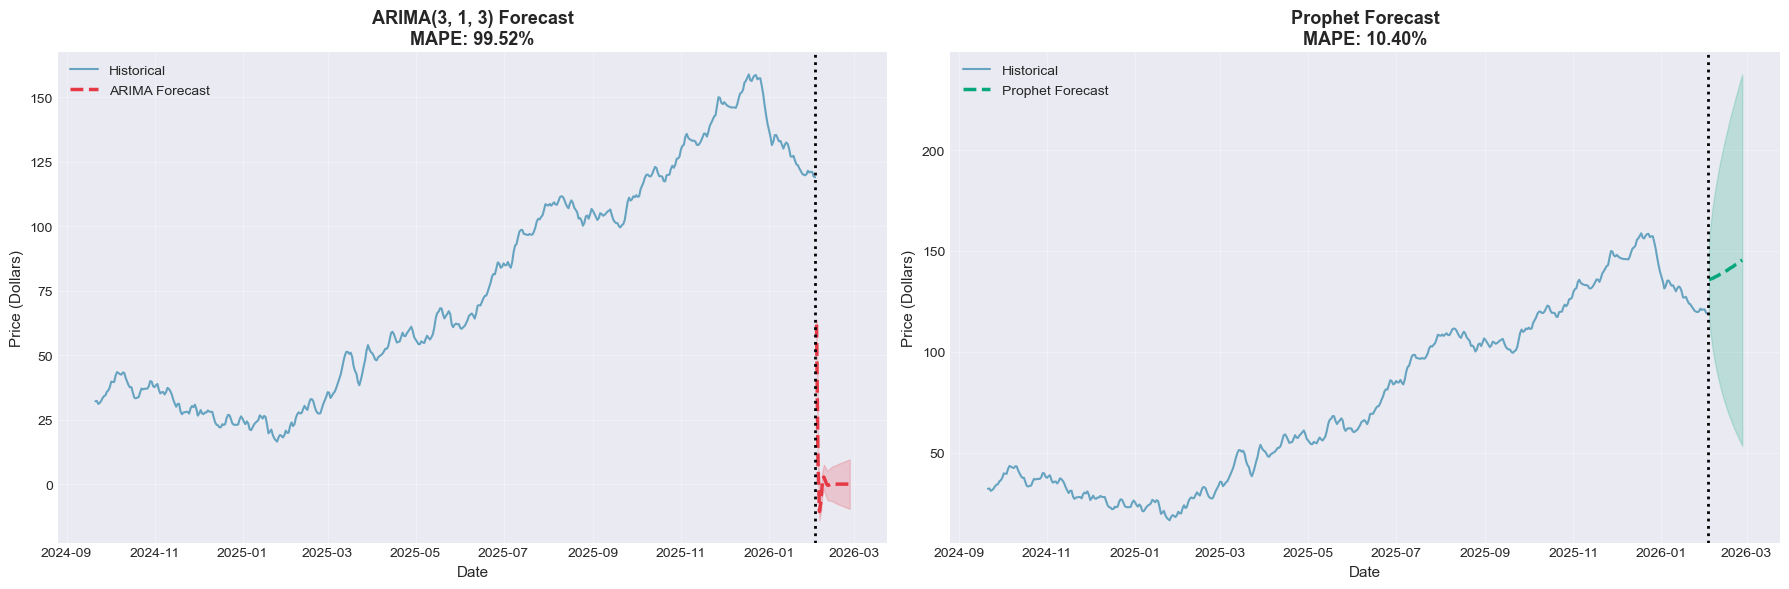

In [160]:
if best_params is not None:
    # Side-by-side forecast comparison
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # ARIMA forecast
    axes[0].plot(df.index, df['price'], label='Historical', 
                 color='#2E86AB', linewidth=1.5, alpha=0.7)
    axes[0].plot(arima_forecast.index, arima_forecast['Forecast'],
                 label='ARIMA Forecast', color='#E63946', linewidth=2.5, linestyle='--')
    axes[0].fill_between(arima_forecast.index,
                         arima_forecast['Lower_CI_95'],
                         arima_forecast['Upper_CI_95'],
                         alpha=0.2, color='#E63946')
    axes[0].axvline(x=df.index[-1], color='black', linestyle=':', linewidth=2)
    axes[0].set_title(f'ARIMA{best_params} Forecast\nMAPE: {arima_metrics["MAPE"]:.2f}%',
                      fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Date', fontsize=11)
    axes[0].set_ylabel('Price (Dollars)', fontsize=11)
    axes[0].legend(loc='best')
    axes[0].grid(True, alpha=0.3)
    
    # Prophet forecast
    axes[1].plot(prophet_df['ds'], prophet_df['y'], label='Historical',
                 color='#2E86AB', linewidth=1.5, alpha=0.7)
    axes[1].plot(prophet_forecast['ds'], prophet_forecast['yhat'],
                 label='Prophet Forecast', color='#06A77D', linewidth=2.5, linestyle='--')
    axes[1].fill_between(prophet_forecast['ds'],
                         prophet_forecast['yhat_lower'],
                         prophet_forecast['yhat_upper'],
                         alpha=0.2, color='#06A77D')
    axes[1].axvline(x=prophet_df['ds'].iloc[-1], color='black', linestyle=':', linewidth=2)
    axes[1].set_title(f'Prophet Forecast\nMAPE: {prophet_metrics["MAPE"]:.2f}%',
                      fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Date', fontsize=11)
    axes[1].set_ylabel('Price (Dollars)', fontsize=11)
    axes[1].legend(loc='best')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('forecast_comparison.png', dpi=300, bbox_inches='tight')
    print('\n✅ Forecast comparison plot saved as "forecast_comparison.png"')
    plt.show()
else:
    print('\n⚠️ Skipping visualization - ARIMA model not available')